[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://githubtocolab.com/NMMLab/nbed-ssro/blob/main/notebook/prediction_example.ipynb)


# Prediction Example

This notebook demonstrates how to download the pretrained NBED-SSRO model and the associated dataset from Hugging Face, load diffraction patterns, and generate predictions for the disorder parameter. If running in Colab, please select a GPU runtime for faster inference.

In [1]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


### Clone the nbed-ssro repository on GitHub

In [2]:
!git clone https://github.com/NMMLab/nbed-ssro
import sys
sys.path.append("nbed-ssro")

from inference import (
    download_model_from_hub,
    load_model_config,
    load_model_from_checkpoint,
    predict)

from train import load_training_data_from_hub

Cloning into 'nbed-ssro'...
remote: Enumerating objects: 35, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 35 (delta 8), reused 25 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (35/35), 12.72 MiB | 18.42 MiB/s, done.
Resolving deltas: 100% (8/8), done.


### Load dataset and model weights from Hugging Face

In [ ]:
weights_path, config_path = download_model_from_hub(
    repo_id="NMMLab/nbed-ssro-model",
    weights_filename="model_state_dict.pt",
    config_filename="model_config.json",
)

config = load_model_config(config_path)

model = load_model_from_checkpoint(
    weights_path=weights_path,
    device=device,
)

X_data, y_data, meta, split_df = load_training_data_from_hub()

### Perform inference on 16 randomly selected data points in the validation subset

In [4]:
import numpy as np

np.random.seed(22)
idx_chosen = np.random.choice(np.nonzero(split_df["split"]=="validation")[0], size=16)

X = X_data[idx_chosen]
y = y_data[idx_chosen]

y_pred = predict(model, X, device=device).reshape(-1, 1)

X = X.cpu().numpy()
y = y.cpu().numpy()

<Figure size 1000x1000 with 0 Axes>

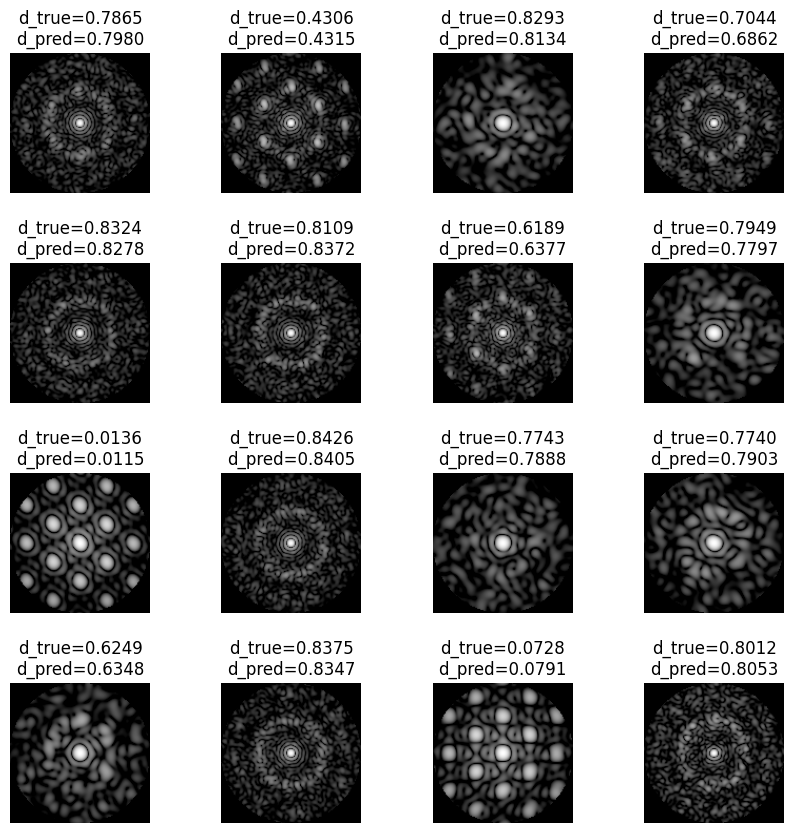

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

fig, ax = plt.subplots(4, 4, figsize=(10, 10))
plt.subplots_adjust(wspace=0.5, hspace=0.5)
for i in range(4):
    for j in range(4):
        idx = i * 4 + j
        ax[i, j].imshow(X[idx, 0, :, :], cmap="gray")
        ax[i, j].axis("off")
        ax[i, j].set_aspect("equal")
        ax[i, j].set_title(f"d_true={(1-y[idx, 0]):.4f}\nd_pred={1-y_pred[idx, 0]:.4f}")

plt.show()